Sphere Least Squares Example
1. Choose a random polynomial f(x,y,z) of degree 4 in 3D space
2. Pick a random sphere in 3D which has 4 degrees of freedom: the position of the origin(3), and the size of the radius. Notice that unlike the ring, the sphere is symmetric on all sides so it does not have an "orientation" per se. 
3. Parametrize the ring by angles theta and phi, which are the colatitude and longitude, and evalutate f on it across a grid of point. We can denote the position of every point on the sphere by marking its angle around the sphere horizontally and its angle around the sphere vertically. (Spherical -> Cartesian)
4. Build a design matrix and solve the least squares problem
5. Also evaluate using a structured grid(Gauss_legendre in theta, uniform in phi) and sht
6. Obtain the mean <f> = p0 and compare to the actual mean that we know since we are choosing the poly
7. Plot the fit, residuals, coefficients

We are given a function f(x, y, z) and a sphere and we want to approximate f on the sphere as a sum of basis functions, where before we approximated f on the ring as a sum of sines and cosines. On the sphere, there are 2 angles, so it is less easy to find the basis functions on its surface. A spherical harmonic is a Fourier mode cos(phi) or sin(phi) in the phi direction times a special polynomial in the theta direction that accounts for the geometry at the poles of a sphere. l is the degree of the spherical harmonic and is the tooal number of oscillations across the whole sphere, m is the order and is how the oscillations split between the theta and phi directions. When m = 0 all variation is in theta, and large |m| means most variation is in phi. 

Examples:

Y(0,0): completely flat, constant over entire sphere - the mean
Y(0,1): positive on the north pole, negative on the south pole, zero at equator - dipole
Y(1,1): positive on one side of the equator, negative on other, oscillates once in phi
Y(0,2): positive at both poles, negative at equator - pumpkin
Y(4,4): oscillates 4 times around the equator, concentrated near the equator

Spherical harmonics are orthogonal over the sphere so its basis functions don't mix and we can recover the coefficients. 

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from itertools import product as iproduct
from scipy.integrate import quad
from scipy.special import sph_harm

Generating the random polynomial, the RNG command basically ensures that we will always get the same randomly generated polynmial when we reset the kernel and run. The limiting factor of the poly is that each term must be of degree 4 or less. This function generates every possible combination of x, y, and z less that degree 4 and then assigns to it a random coeffcient. The inner function just assigns each coefficient to each monomial and sums them. 

In [23]:
RNG = np.random.default_rng(42)
def make_random_poly(degree=4, rng=RNG):
    monomials = [(a, b, c)
                 for a, b, c in iproduct(range(degree+1), repeat=3)
                 if a + b + c <= degree]
    coeffs = rng.standard_normal(len(monomials))

    def f(x, y, z):
        x, y, z = np.asarray(x), np.asarray(y), np.asarray(z)
        val = np.zeros_like(x, dtype=float)
        for (a, b, c), coef in zip(monomials, coeffs):
            val = val + coef * (x**a) * (y**b) * (z**c)
        return val

    return f, monomials, coeffs

Generating a random sphere which has 4 degrees of freedom, and parametrizing it using its colatitude and latitude(theta and phi).

In [26]:
def make_random_sphere(rng=RNG):

    center = rng.uniform(-2, 2, size=3)
    radius = rng.uniform(0.5, 3.0)
    return center, radius

def sphere_points(center, radius, theta, phi):
    theta = np.asarray(theta).ravel()
    phi = np.asarray(phi).ravel()
    x = center[0] + radius * np.sin(theta) * np.cos(phi) # center[0] is the position of the sphere's center in the x-direction
    y = center[1] + radius * np.sin(theta) * np.sin(phi)
    z = center[2] + radius * np.cos(theta)
    return np.column_stack([x, y, z])

The first function selects points by selecting theta and phi completely randomly. Notice that this will lead to oversaturation of points selected near the poles. The second function structures the randomness using theta = arccos(uniform(-1,1)) to select points that are uniformly distributed by area NOT angle, this means that our points get more uniformly distributed across the sphere rather than clumping near the poles. This is important because we want our approximation to fit the polynomial over the entire sphere and not be weighted towards the poles.  

Recall for the torus design on the ring, uniform points made the integral for each Fourier coefficent exact. We want to exploit a similar symmetry to compute the spherical harmonic coeffcients exactly as well. This is trickier since we need our integrals in both phi and theta to be exact. Start by approximating the integral using Gauss-Legendre quadrature(this is quite similar to Newton-Coates/trapezoidal rules) which is exact when our polynomials is of degree <= 2N - 1, where N is how many nodes we have in our sum, in our case how many points we are sampling on the sphere. x_k are the roots of the Legendre polynomial and are not uniformly spaced, they cluster near endpoints. We then convert the nodes into theta to obtain the uniform points in theta. For the uniform points in phi, we use the same ring torus sampling, and we can use DFT to compute the integral which is once agian exact because of the orthogonality condition. Finally, we combine our uniform points in theta with our uniform points in phi to build a 2d grid of all our points. 

In [29]:
# complete randomness
def sample_sphere_random(f, center, radius, N_samples, rng = RNG):
    phi = rng.uniform(0, 2*np.pi, N_samples)
    theta = rng.uniform(0, np.pi, N_samples)
    pts = sphere_points(center, radius, theta, phi)
    y = f(pts[:, 0], pts[:, 1], pts[:, 2])
    return theta, phi, y
    
# uniform random points 
def sample_sphere_unrandom(f, center, radius, N_samples, rng = RNG):
    phi = rng.uniform(0, 2*np.pi, N_samples)
    theta = np.arccos(rng.uniform(-1, 1, N_samples))
    pts = sphere_points(center, radius, theta, phi)
    y = f(pts[:, 0], pts[:, 1], pts[:, 2])
    return theta, phi, y

# torus structured points
def sample_sphere_torus(center, radius, N_theta, N_phi):
    gl_nodes, gl_weights = np.polynomial.legendre.leggauss(N_theta)
    theta = np.arccos(gl_nodes)
    phi = np.linspace(0, 2*np.pi, N_phi, endpoint=False)

    THETA, PHI = np.meshgrid(theta, phi, indexing = 'ij')
    return THETA, PHI, theta, phi, gl_weights

Creating the design matrix(N, 2M + 1), where each row is just the function evaluated at each angle not including the unknown coefficients which are contained within the column vector x. Solve the least squares problem
to obtain x_hat, residual_norm, A, and rank.

In [93]:
def build_sphere_design_matrix(theta,phi, L):
    theta = np.asarray(theta).ravel()
    phi = np.asarray(phi).ravel()
    cols = []
    for l in range(L+1):
        for m in range(-l, l+1):
            if m < 0:
                Y = np.sqrt(2) * np.imag(sph_harm(abs(m), l, phi, theta))
            elif m == 0:
                Y = np.real(sph_harm(0, l, phi, theta))
            else:
                Y = np.sqrt(2) * np.real(sph_harm(m, l, phi, theta))
            cols.append(Y)
    return np.column_stack(cols)


def solve_sphere_lstsq(theta, phi, y, L):
    A = build_sphere_design_matrix(theta, phi, L)
    x_hat, _, rank, sv = np.linalg.lstsq(A, y, rcond=None)
    residual_norm = np.linalg.norm( A @ x_hat - y)
    return x_hat, residual_norm, A, rank, sv

def sample_sphere_torus_and_sht(f, center, radius, N_theta, N_phi, L):
    THETA, PHI, theta, phi, gl_weights = sample_sphere_torus(center, radius, N_theta, N_phi)

    pts = sphere_points(center, radius, THETA.ravel(), PHI.ravel())
    y = f(pts[:, 0], pts[:, 1], pts[:, 2]).reshape(N_theta, N_phi)

    coeffs = []
    for l in range(L+1):
        for m in range(-l, l+1):
            if m < 0: 
                Y = np.sqrt(2) * np.imag(sph_harm(abs(m), l, PHI, THETA))
            elif m ==0: 
                Y = np.real(sph_harm(0, l, PHI, THETA))
            else: 
                Y = np.sqrt(2) * np.real(sph_harm(m, l, PHI, THETA))

            integrand = y * Y
            phi_sum = np.sum(integrand, axis = 1) * (2*np.pi / N_phi)
            c = np.dot(gl_weights, phi_sum)
            coeffs.append(c)
    return np.array(coeffs), THETA, PHI, y

def eval_sphere(theta, phi, coeffs, L):
    A = build_sphere_design_matrix(theta, phi, L)
    return A @ coeffs

Evaluating f at N points at uniformly spaced angles along the ring which is the torus design. As a result, the columns of our design matrix will be exactly orthogonal so the least squares solution will give us the correct Fourier coefficients.

In [96]:
f, monomials, coeffs = make_random_poly()
center, radius = make_random_sphere()

L = 8
N_samples = 400
N_theta = 20
N_phi = 40

theta_rand, phi_rand, y_rand = sample_sphere_random(f, center, radius, N_samples)
x_hat_rand, residual_norm_rand, A_rand, rank_rand, sv_rand = solve_sphere_lstsq(theta_rand, phi_rand, y_rand, L)

theta_unrand, phi_unrand, y_unrand = sample_sphere_unrandom(f, center, radius, N_samples)
x_hat_unrand, residual_norm_unrand, A_unrand, rank_unrand, sv_unrand = solve_sphere_lstsq(theta_unrand, phi_unrand, y_unrand, L)

sht_coeffs, THETA, PHI, y_grid = sample_sphere_torus_and_sht(f, center, radius, N_theta, N_phi, L)

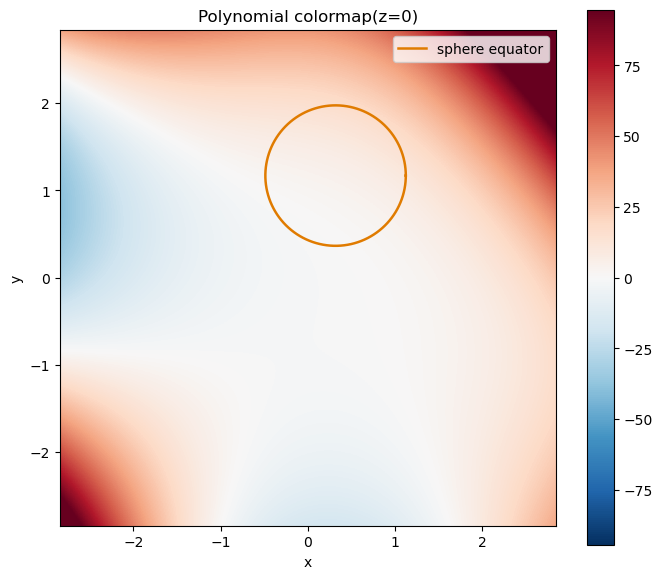

In [98]:
# Polynomial colormap
ext = radius + np.linalg.norm(center) + 0.5
xs, ys = np.linspace(-ext, ext, 300), np.linspace(-ext, ext, 300)
X, Y = np.meshgrid(xs, ys)
Z = f(X.ravel(), Y.ravel(), np.zeros(X.size)).reshape(X.shape)

fig, ax = plt.subplots(figsize = (7, 6))
vmax = np.percentile(np.abs(Z), 98)
im = ax.imshow(Z, origin = "lower", extent = [-ext, ext, -ext, ext], 
               cmap = "RdBu_r", vmin = -vmax, vmax = vmax)
fig.colorbar(im, ax = ax)

phi_eq = np.linspace(0, 2*np.pi, 500)
theta_eq = np.full(500, np.pi/2)
pts_eq = sphere_points(center, radius, theta_eq, phi_eq)
ax.plot(pts_eq[:, 0], pts_eq[:, 1], color = "#e07b00", lw=1.8, label = "sphere equator")

ax.set(title = "Polynomial colormap(z=0)", xlabel = "x", ylabel = "y")
ax.legend()
plt.tight_layout()
plt.show()

The polynomial colormap projects the 3d polynomial of degree 4 onto an x-y plane by fixing a z, in this case z = 0, and then evaluating the f(x, y, 0) at each location and denoting it by a color. 

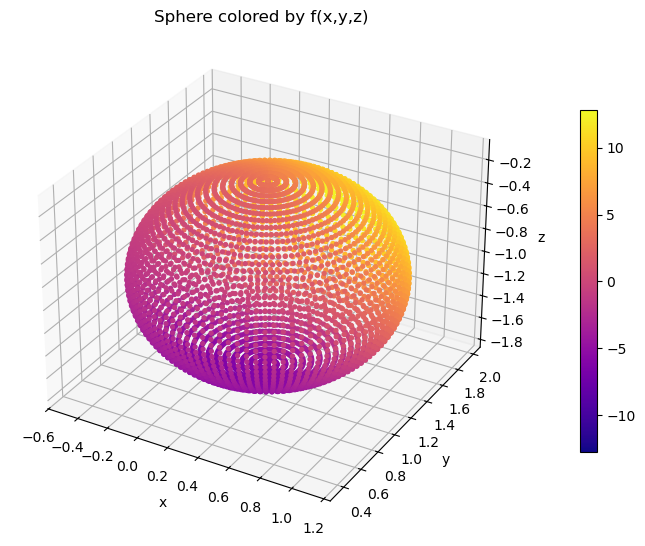

In [101]:
# 3D ring
phi_sph = np.linspace(0, 2*np.pi, 100, endpoint=False)
theta_sph = np.linspace(0, np.pi, 50)
THETA_sph, PHI_sph = np.meshgrid(theta_sph, phi_sph, indexing = 'ij')
pts_sph      = sphere_points(center, radius, THETA_sph.ravel(), PHI_sph.ravel())
f_vals   = f(pts_sph[:, 0], pts_sph[:, 1], pts_sph[:, 2])

fig = plt.figure(figsize=(7, 6))
ax  = fig.add_subplot(111, projection="3d")
vr  = np.abs(f_vals).max()
ax.scatter(pts_sph[:, 0], pts_sph[:, 1], pts_sph[:, 2],
           c=f_vals, cmap="plasma", vmin=-vr, vmax=vr, s=8, depthshade=False)
sm = plt.cm.ScalarMappable(cmap = "plasma", norm = plt.Normalize(-vr, vr))
sm.set_array([])
fig.colorbar(sm, ax = ax, shrink = 0.6, pad = 0.1)
ax.set(title="Sphere colored by f(x,y,z)", xlabel="x", ylabel="y", zlabel="z")
plt.tight_layout()
plt.show()

The 3D ring plot shows us where the ring lives in 3d space and the values of (f, x, z) at each point along it

Naive random residual:   0.000000
Uniform random residual: 0.000000
Torus + SHT residual:    0.000000


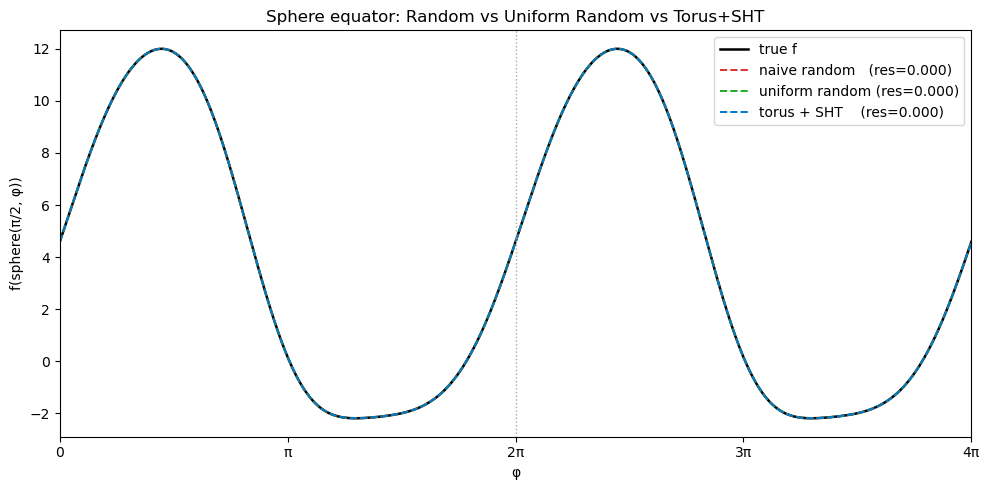

In [104]:
res_rand   = np.linalg.norm(eval_sphere(theta_rand,   phi_rand,   x_hat_rand,   L) - y_rand)
res_unrand = np.linalg.norm(eval_sphere(theta_unrand, phi_unrand, x_hat_unrand, L) - y_unrand)
res_sht    = np.linalg.norm(eval_sphere(THETA.ravel(), PHI.ravel(), sht_coeffs,  L) - y_grid.ravel())

print(f"Naive random residual:   {res_rand:.6f}")
print(f"Uniform random residual: {res_unrand:.6f}")
print(f"Torus + SHT residual:    {res_sht:.6f}")

phi_dense = np.linspace(0, 4*np.pi, 2000)
theta_eq = np.full(2000, np.pi/2)

pts_dense = sphere_points(center, radius, theta_eq, phi_dense)
y_true_eq = f(pts_dense[:, 0], pts_dense[:, 1], pts_dense[:, 2])

y_rand_approx = eval_sphere(theta_eq, phi_dense, x_hat_rand, L)
y_unrand_approx = eval_sphere(theta_eq, phi_dense, x_hat_unrand, L)
y_sht_approx = eval_sphere(theta_eq, phi_dense, sht_coeffs, L)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(phi_dense, y_true_eq,       color="black",   lw=1.8, label="true f")
ax.plot(phi_dense, y_rand_approx,   color="#e03030", lw=1.4, linestyle="--", label=f"naive random   (res={res_rand:.3f})")
ax.plot(phi_dense, y_unrand_approx, color="#22aa22", lw=1.4, linestyle="--", label=f"uniform random (res={res_unrand:.3f})")
ax.plot(phi_dense, y_sht_approx,    color="#0077cc", lw=1.4, linestyle="--", label=f"torus + SHT    (res={res_sht:.3f})")
ax.axvline(2*np.pi, color="#aaaaaa", lw=1.0, linestyle=":")
ax.set_xticks([0, np.pi, 2*np.pi, 3*np.pi, 4*np.pi])
ax.set_xticklabels(["0", "π", "2π", "3π", "4π"])
ax.set(xlabel="φ", ylabel="f(sphere(π/2, φ))", 
       title="Sphere equator: Random vs Uniform Random vs Torus+SHT",
       xlim=(0, 4*np.pi))
ax.legend()
plt.tight_layout()
plt.show()

Notice that our approximation is exactly the same as the actual f because the function that we are sampling angles from is a polynomial, hence it can be exactly approximated by sines and cosines. 